In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Na_mu_B = 6.022*10**(23)*9.274*10**(-21) # Pra passar de emu/mol para mu_B/F.U.

In [2]:
23.7*10**(3)/Na_mu_B

4.243659238961849

In [3]:
# Dados magnetização experimental
mag_3K_exp  = pd.read_csv("Magnetizacao_Exp_3K.csv")
mag_10K_exp = pd.read_csv("Magnetizacao_Exp_10K.csv")
# Dados magnetização simulação
mag_3K_sim  = pd.read_csv("Magnetizacao_Sim_3K.csv")
mag_10K_sim = pd.read_csv("Magnetizacao_Sim_10K.csv")
# Dados susceptibilidade
chit_100Oe = pd.read_csv("ChiT_Fit.dat",sep = '\s+')

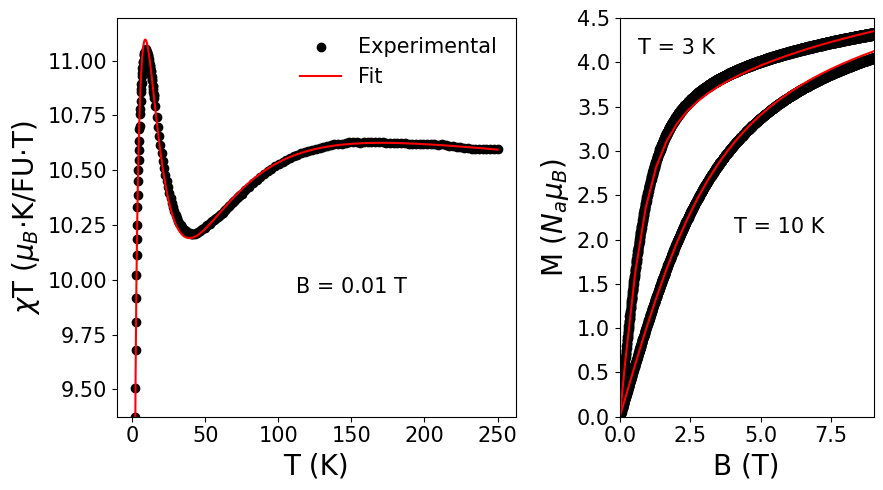

In [5]:
# Create a figure and a set of subplots (1 row, 2 columns)
# fig is the entire figure, (ax1, ax2) are the two individual axes (plots)
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(9, 5),                # tamanho TOTAL da figura
    gridspec_kw={'width_ratios': [1, 0.6]}  # ax2 mais curto
)
ax1.set_box_aspect(1)
# Plot data on the first subplot (left)
ax1.scatter(chit_100Oe['Temperature(K)'], (10**(4)*chit_100Oe['ChiT_Data(emu.K/mol.Oe)']/(Na_mu_B)), color='black',label='Experimental')
ax1.plot(chit_100Oe['Temperature(K)'], (10**(4)*chit_100Oe['ChiT_Model(emu.K/mol.Oe)']/(Na_mu_B)), color='red', label='Fit')
ax1.set_ylim(min(10**(4)*chit_100Oe['ChiT_Data(emu.K/mol.Oe)']/(Na_mu_B)))
ax1.text(
    0.45, 0.35,
    r'B = 0.01 T',
    transform=ax1.transAxes,
    fontsize=15,
    verticalalignment='top'
)


ax1.set_xlabel('T (K)',fontsize=20)
ax1.set_ylabel(r'$\chi$T ($\mu_B$$\cdot$K/FU$\cdot$T)',fontsize=20)
ax1.legend(
    loc='upper right',
    fontsize=15,
    frameon=False
)

# Plot data on the second subplot (right)
ax2.scatter(mag_3K_exp['B_exp (T)'], mag_3K_exp['M_exp (emu/mol)']/(Na_mu_B), color='black')
ax2.scatter(mag_10K_exp['B_exp (T)'], mag_10K_exp['M_exp (emu/mol)']/(Na_mu_B), color='black')
ax2.plot(mag_3K_sim['B_sim (T)'], mag_3K_sim['M_sim (emu/mol)']/(Na_mu_B), color='red')
ax2.plot(mag_10K_sim['B_sim (T)'], mag_10K_sim['M_sim (emu/mol)']/(Na_mu_B), color='red')

ax2.text(
    0.07, 0.95,
    r'T = 3 K',
    transform=ax2.transAxes,
    fontsize=15,
    verticalalignment='top'
)
ax2.text(
    0.45, 0.5,
    r'T = 10 K',
    transform=ax2.transAxes,
    fontsize=15,
    verticalalignment='top'
)

ax2.set_xlabel('B (T)',fontsize=20)
ax2.set_ylabel(r'M ($N_a \mu_B$)',fontsize=20)
ax2.set_xlim(0,9)
ax2.set_ylim(0,4.5)
ax1.tick_params(axis='both', which='major', labelsize=15)
ax2.tick_params(axis='both', which='major', labelsize=15)
#ax2.set_x_lim(0,9)
# Adjust layout to prevent titles and labels from overlapping
plt.tight_layout() #
plt.savefig('fig_v2.pdf')
# Display the plots
plt.show()
